In [101]:
import os
import shutil
import random
from pathlib import Path
import numpy as np

import pandas as pd
from sklearn.model_selection import GroupKFold
from PIL import Image, ImageEnhance, ImageFilter

from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

## Step 1: Inspecting metadata

In [3]:
csv_file = r"C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\Labels.csv"

df = pd.read_csv(csv_file)
print(df.head())
print(df.columns)
print(df.shape)

  Image Name  Patient Label  Quality Score
0    0_0.jpg        0  GON+           6.18
1    1_0.jpg        1  GON+           5.31
2    1_1.jpg        1  GON+           4.37
3    2_0.jpg        2  GON+           3.51
4    2_1.jpg        2  GON+           4.24
Index(['Image Name', 'Patient', 'Label', 'Quality Score'], dtype='object')
(747, 4)


In [5]:
df = df.rename(columns={
    "Image Name": "image_name",
    "Patient": "patient_id",
    "Label": "label",
    "Quality Score": "quality_score"
})

print(df[["image_name", "patient_id", "label", "quality_score"]].head())

  image_name  patient_id label  quality_score
0    0_0.jpg           0  GON+           6.18
1    1_0.jpg           1  GON+           5.31
2    1_1.jpg           1  GON+           4.37
3    2_0.jpg           2  GON+           3.51
4    2_1.jpg           2  GON+           4.24


In [7]:
print("Class distribution:")
print(df["label"].value_counts())

print("\nPatients:", df["patient_id"].nunique())
print("Images:", len(df))

print("\nQuality score summary:")
print(df["quality_score"].describe())

Class distribution:
label
GON+    548
GON-    199
Name: count, dtype: int64

Patients: 288
Images: 747

Quality score summary:
count    747.000000
mean       5.904311
std        1.007189
min        2.040000
25%        5.365000
50%        6.180000
75%        6.630000
max        7.690000
Name: quality_score, dtype: float64


We have 288 patients, but we have up to 747 images - one patient may have few images



From the quality score summary, we can deduce that:
1. min = 2.04 (worst image quality)
2. mean = 5.9 (average image quality)
3. max = 7.69 (best image quality)

## Step 2: Data Visualization

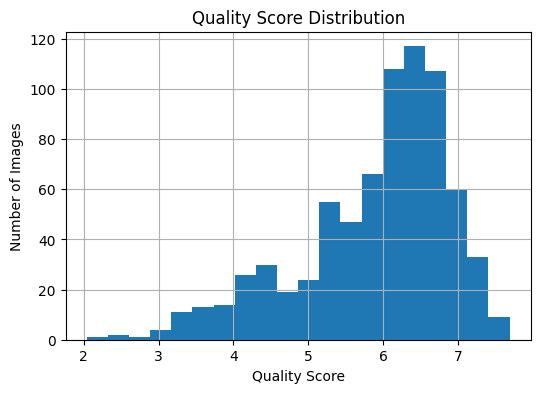

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["quality_score"].hist(bins=20)
plt.title("Quality Score Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Number of Images")
plt.show()

There are not much images scored lower quality - most of our image is in good quality!

Most images have quality scores above 5, indicating that the dataset generally contains good-quality retinal images.

In [14]:
df.groupby("label")["quality_score"].mean()

label
GON+    5.844088
GON-    6.070151
Name: quality_score, dtype: float64

The difference in quality between GON+ and GON− images is small (≈0.23), suggesting that image quality is unlikely to influence the classification outcome. Therefore, filtering images with quality_score ≥ 5 is sufficient to remove poor-quality images while retaining most of the dataset.

Filter out poor quality images

The number of images before fitering out the low quality

In [18]:
df["label"].value_counts() ##before removing low quality

label
GON+    548
GON-    199
Name: count, dtype: int64

The number of images after filtering out the low quality

In [20]:
df_clean = df[df["quality_score"] >= 5].copy()

print("Original images:", len(df))
print("Filtered images:", len(df_clean))
print("\nLabel distribution after filtering:")
print(df_clean["label"].value_counts())
print("\nPatients after filtering:", df_clean["patient_id"].nunique())

Original images: 747
Filtered images: 618

Label distribution after filtering:
label
GON+    439
GON-    179
Name: count, dtype: int64

Patients after filtering: 260


## Step 3: Addressing imbalance dataset

We did kfold cross validation to obtain a more reliable and unbiased evaluation of the model. Instead of relying on a single train–validation split, the dataset is divided into multiple folds, and the model is trained and evaluated across different subsets of the data. In addition, GroupKFold is used to ensure that images from the same patient do not appear in both training and validation sets, preventing data leakage and improving generalization. Although cross-validation improves evaluation reliability, class imbalance is addressed separately during the training phase.

In [32]:
from sklearn.model_selection import GroupKFold

X = df_clean["image_name"]
y = df_clean["label"]
groups = df_clean["patient_id"]

gkf = GroupKFold(n_splits=5)

fold_data = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):
    train_df = df_clean.iloc[train_idx].copy()
    val_df = df_clean.iloc[val_idx].copy()
    
    fold_data.append((train_df, val_df))
    
    print(f"Fold {fold}")
    print("Train images:", len(train_df))
    print("Val images:", len(val_df))
    print("Train patients:", train_df["patient_id"].nunique())
    print("Val patients:", val_df["patient_id"].nunique())
    print("Train label distribution:")
    print(train_df["label"].value_counts())
    print("Val label distribution:")
    print(val_df["label"].value_counts())
    print("-" * 40)

Fold 1
Train images: 494
Val images: 124
Train patients: 208
Val patients: 52
Train label distribution:
label
GON+    352
GON-    142
Name: count, dtype: int64
Val label distribution:
label
GON+    87
GON-    37
Name: count, dtype: int64
----------------------------------------
Fold 2
Train images: 494
Val images: 124
Train patients: 208
Val patients: 52
Train label distribution:
label
GON+    354
GON-    140
Name: count, dtype: int64
Val label distribution:
label
GON+    85
GON-    39
Name: count, dtype: int64
----------------------------------------
Fold 3
Train images: 494
Val images: 124
Train patients: 208
Val patients: 52
Train label distribution:
label
GON+    357
GON-    137
Name: count, dtype: int64
Val label distribution:
label
GON+    82
GON-    42
Name: count, dtype: int64
----------------------------------------
Fold 4
Train images: 495
Val images: 123
Train patients: 208
Val patients: 52
Train label distribution:
label
GON+    352
GON-    143
Name: count, dtype: int64
Val

In this cell, few components were established:
1. augment_image(img): Applies mild augmentation to fundus images, including small rotation, brightness, contrast, sharpness adjustment, and slight blur, to generate additional minority-class training samples while preserving important clinical features.

2. create_classification_folders(output_dir, classes): Creates the folder structure required for YOLO classification by generating train and val directories with class-specific subfolders.

3. copy_original_images(df_split, split_name, image_dir, output_dir): Copies original images into the appropriate training or validation class folders based on the dataframe labels, while also reporting missing files.

4. balance_training_data_with_augmentation(train_df, image_dir, output_dir, random_state=42): Balances the training set by augmenting minority-class images until the class distribution matches that of the majority class. This is applied only to the training subset of each fold.

5. print_folder_counts(output_dir, classes): Displays the number of images in each class folder for the training and validation sets to verify correct dataset preparation and balancing.

In [44]:
import os

def augment_image(img):
    """
    Mild augmentation for fundus/classification images.
    Avoid overly aggressive transforms.
    """
    # random rotation
    angle = random.uniform(-10, 10)
    img = img.rotate(angle)

    # brightness
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.9, 1.1))

    # contrast
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.9, 1.1))

    # sharpness
    enhancer = ImageEnhance.Sharpness(img)
    img = enhancer.enhance(random.uniform(0.9, 1.2))

    # optional slight blur
    if random.random() < 0.2:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 0.8)))

    return img

def create_classification_folders(output_dir, classes):
    for split in ["train", "val"]:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)


def copy_original_images(df_split, split_name, image_dir, output_dir):
    missing = []
    copied = 0

    for _, row in df_split.iterrows():
        src = os.path.join(image_dir, row["image_name"])
        dst = os.path.join(output_dir, split_name, row["label"], row["image_name"])

        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied += 1
        else:
            missing.append(row["image_name"])

    print(f"{split_name.upper()} copied: {copied}")
    print(f"{split_name.upper()} missing: {len(missing)}")
    return missing

def balance_training_data_with_augmentation(train_df, image_dir, output_dir, random_state=42):
    random.seed(random_state)

    class_counts = train_df["label"].value_counts()
    print("\nOriginal TRAIN class counts:")
    print(class_counts)

    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()
    majority_count = class_counts.max()
    minority_count = class_counts.min()

    minority_df = train_df[train_df["label"] == minority_class].copy()

    needed = majority_count - minority_count
    print(f"\nMinority class: {minority_class}")
    print(f"Majority class: {majority_class}")
    print(f"Need to generate {needed} augmented images")

    if needed <= 0:
        print("Training set already balanced.")
        return

    minority_rows = minority_df.sample(n=needed, replace=True, random_state=random_state).reset_index(drop=True)

    save_dir = os.path.join(output_dir, "train", minority_class)

    generated = 0
    missing = []

    for i, row in minority_rows.iterrows():
        src = os.path.join(image_dir, row["image_name"])

        if not os.path.exists(src):
            missing.append(row["image_name"])
            continue

        try:
            img = Image.open(src).convert("RGB")
            aug_img = augment_image(img)

            stem = Path(row["image_name"]).stem
            ext = Path(row["image_name"]).suffix
            new_name = f"{stem}_aug_{i}{ext}"
            dst = os.path.join(save_dir, new_name)

            aug_img.save(dst)
            generated += 1

        except Exception as e:
            print(f"Error processing {row['image_name']}: {e}")

    print(f"Generated augmented minority images: {generated}")
    print(f"Missing minority source images: {len(missing)}")

def print_folder_counts(output_dir, classes):
    for split in ["train", "val"]:
        print(f"\n{split.upper()} counts:")
        for cls in classes:
            class_folder = os.path.join(output_dir, split, cls)
            count = len(os.listdir(class_folder)) if os.path.exists(class_folder) else 0
            print(f"{cls}: {count}")

In [50]:
image_dir = r"C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\Images"
base_output_dir = r"C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma"
classes = sorted(df_clean["label"].unique())

for fold_idx, (train_df, val_df) in enumerate(fold_data, start=1):
    print(f"\n{'='*60}")
    print(f"Preparing Fold {fold_idx}")
    print(f"{'='*60}")

    output_dir = os.path.join(base_output_dir, f"dataset_yolo_fold{fold_idx}_balanced")

    # optional: remove old folder if it already exists
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)

    create_classification_folders(output_dir, classes)

    # copy original images
    copy_original_images(train_df, "train", image_dir, output_dir)
    copy_original_images(val_df, "val", image_dir, output_dir)

    # balance only training split
    balance_training_data_with_augmentation(train_df, image_dir, output_dir, random_state=42 + fold_idx)

    # show final counts
    print_folder_counts(output_dir, classes)


Preparing Fold 1
TRAIN copied: 494
TRAIN missing: 0
VAL copied: 124
VAL missing: 0

Original TRAIN class counts:
label
GON+    352
GON-    142
Name: count, dtype: int64

Minority class: GON-
Majority class: GON+
Need to generate 210 augmented images
Generated augmented minority images: 210
Missing minority source images: 0

TRAIN counts:
GON+: 352
GON-: 352

VAL counts:
GON+: 87
GON-: 37

Preparing Fold 2
TRAIN copied: 494
TRAIN missing: 0
VAL copied: 124
VAL missing: 0

Original TRAIN class counts:
label
GON+    354
GON-    140
Name: count, dtype: int64

Minority class: GON-
Majority class: GON+
Need to generate 214 augmented images
Generated augmented minority images: 214
Missing minority source images: 0

TRAIN counts:
GON+: 354
GON-: 354

VAL counts:
GON+: 85
GON-: 39

Preparing Fold 3
TRAIN copied: 494
TRAIN missing: 0
VAL copied: 124
VAL missing: 0

Original TRAIN class counts:
label
GON+    357
GON-    137
Name: count, dtype: int64

Minority class: GON-
Majority class: GON+
Nee

Here, we have balanced dataset for both class

## Step 4: YOLO Classification

The model was trained using the You Only Look Once (YOLO) classification framework, which is known for its computational efficiency and lightweight architecture. This enables faster inference and reduced model complexity while maintaining competitive accuracy, making it suitable for real-time and resource-constrained applications.

For this programme, we implemented YOLO11 as our classifier, we did two version of YOLO11 model, baseline model and improved model to achieve better accuracy with lighter model for deployment.

Both model were evaluated using 5 fold cross validation.

### YOLO11 baseline model training

In [51]:
model_yaml = r"C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\venv\Lib\site-packages\ultralytics\cfg\models\11\yolo11-cls.yaml"

for fold_idx in range(1, 6):
    print(f"\n{'='*60}")
    print(f"Training Fold {fold_idx} baseline on balanced data")
    print(f"{'='*60}")

    data_dir = os.path.join(base_output_dir, f"dataset_yolo_fold{fold_idx}_balanced")

    model = YOLO(model_yaml)
    model.train(
        data=data_dir,
        epochs=100,
        imgsz=224,
        name=f"Fold_{fold_idx}_baseline_balanced"
    )


Training Fold 1 baseline on balanced data
WARNING  no model scale passed. Assuming scale='n'.
YOLO11-cls summary: 151 layers, 1,533,666 parameters, 1,533,666 gradients, 3.3 GFLOPs
New https://pypi.org/project/ultralytics/8.4.23 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.12  Python-3.12.3 torch-2.4.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: task=classify, mode=train, model=C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\venv\Lib\site-packages\ultralytics\cfg\models\11\yolo11-cls.yaml, data=C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold1_balanced, epochs=100, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=Fold_1_baseline_balanced, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, prof

train: Scanning C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold1_balanced\train... 704 images, 0 

train: New cache created: C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold1_balanced\train.cache



val: Scanning C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold1_balanced\val... 124 images, 0 corr


val: New cache created: C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold1_balanced\val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\Fold_1_baseline_balanced
Starting training for 100 epochs...

      Epoch    GPU_mem       loss  Instances       Size


...

    100/100     0.277G      0.214         10        224: 100%|██████████| 43/43 [00:21<00:00,  1.99it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 4/4 [00:00<00:00, 11.94it/s]

                   all      0.935          1



100 epochs completed in 0.745 hours.
Optimizer stripped from runs\classify\Fold_5_baseline_balanced\weights\last.pt, 3.2MB
Optimizer stripped from runs\classify\Fold_5_baseline_balanced\weights\best.pt, 3.2MB

Validating runs\classify\Fold_5_baseline_balanced\weights\best.pt...
WARNING  validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.12  Python-3.12.3 torch-2.4.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11-cls summary (fused): 112 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold5_balanced\train... found 682 images in 2 classes  
val: C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold5_balanced\val... found 123 images in 2 classes  
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 4/4 [00:00<00:00,  5.30it/s]


                   all      0.943          1
Speed: 0.7ms preprocess, 4.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\Fold_5_baseline_balanced
Results saved to runs\classify\Fold_5_baseline_balanced


### YOLO11 improved model training

In [54]:
improved_yaml = r"C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\venv\Lib\site-packages\ultralytics\cfg\models\11\yolo11-cls-improved.yaml"

for fold_idx in range(1, 6):
    print(f"\n{'='*60}")
    print(f"Training Fold {fold_idx} improved on balanced data")
    print(f"{'='*60}")

    data_dir = os.path.join(base_output_dir, f"dataset_yolo_fold{fold_idx}_balanced")

    model = YOLO(improved_yaml)
    model.train(
        data=data_dir,
        epochs=100,
        imgsz=224,
        name=f"Fold_{fold_idx}_improved_balanced"
    )


Training Fold 1 improved on balanced data
WARNING  no model scale passed. Assuming scale='n'.
YOLO11-cls-improved summary: 139 layers, 816,706 parameters, 816,706 gradients, 1.3 GFLOPs
New https://pypi.org/project/ultralytics/8.4.23 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.12  Python-3.12.3 torch-2.4.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: task=classify, mode=train, model=C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\venv\Lib\site-packages\ultralytics\cfg\models\11\yolo11-cls-improved.yaml, data=C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold1_balanced, epochs=100, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=Fold_1_improved_balanced, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, frac

train: Scanning C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold1_balanced\train... 704 images, 0 
val: Scanning C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold1_balanced\val... 124 images, 0 corr


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 37 weight(decay=0.0), 38 weight(decay=0.0005), 38 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\Fold_1_improved_balanced
Starting training for 100 epochs...

      Epoch    GPU_mem       loss  Instances       Size


      1/100     0.287G     0.6928         16        224: 100%|██████████| 44/44 [00:35<00:00,  1.22it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 4/4 [00:02<00:00,  1.77it/s]

                   all      0.702          1


...

    100/100     0.268G     0.2556         10        224: 100%|██████████| 43/43 [00:21<00:00,  1.96it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 4/4 [00:00<00:00,  8.96it/s]

                   all      0.959          1



100 epochs completed in 0.747 hours.
Optimizer stripped from runs\classify\Fold_5_improved_balanced\weights\last.pt, 1.8MB
Optimizer stripped from runs\classify\Fold_5_improved_balanced\weights\best.pt, 1.8MB

Validating runs\classify\Fold_5_improved_balanced\weights\best.pt...
WARNING  validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.12  Python-3.12.3 torch-2.4.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11-cls-improved summary (fused): 102 layers, 811,746 parameters, 0 gradients, 1.2 GFLOPs
train: C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold5_balanced\train... found 682 images in 2 classes  
val: C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma\dataset_yolo_fold5_balanced\val... found 123 images in 2 classes  
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 4/4 [00:00<00:00,  4.08it/s]


                   all      0.959          1
Speed: 1.1ms preprocess, 2.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\Fold_5_improved_balanced
Results saved to runs\classify\Fold_5_improved_balanced


## Step 5: Evaluation Metrics

This pipeline evaluates the YOLO classification model across multiple folds by generating predictions on validation data, computing performance metrics, and summarizing the results using mean and standard deviation to assess overall performance and stability.

### YOLO11 baseline model

In [105]:
base_output_dir = r"C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma"

runs_dir = os.path.join(base_output_dir, "runs", "classify")

dataset_prefix = "dataset_yolo_fold"
dataset_suffix = "_balanced"

run_name_pattern = "Fold_{fold}_baseline_balanced"

n_folds = 5

def get_true_labels_and_paths(val_dir):
    """
    Read validation images from:
        val/
          classA/
          classB/

    Returns:
        image_paths: list of image file paths
        y_true: list of integer labels
        class_names: sorted class folder names
        class_to_idx: mapping class name -> integer label
    """
    val_path = Path(val_dir)

    class_names = sorted([p.name for p in val_path.iterdir() if p.is_dir()])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    image_paths = []
    y_true = []

    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    for cls_name in class_names:
        cls_dir = val_path / cls_name
        for img_path in cls_dir.rglob("*"):
            if img_path.suffix.lower() in valid_exts:
                image_paths.append(str(img_path))
                y_true.append(class_to_idx[cls_name])

    return image_paths, y_true, class_names, class_to_idx

def predict_fold(model_path, image_paths):
    """
    Run YOLO classification prediction on a list of image paths.
    Returns predicted class indices.
    """
    model = YOLO(model_path)

    results = model.predict(
        source=image_paths,
        stream=False,
        verbose=False
    )

    y_pred = []
    for r in results:
        pred_idx = int(r.probs.top1)
        y_pred.append(pred_idx)

    return y_pred

for fold in range(1, n_folds + 1):
    print(f"\n{'='*60}")
    print(f"Evaluating Fold {fold}")
    print(f"{'='*60}")

    model_path = os.path.join(
        runs_dir,
        run_name_pattern.format(fold=fold),
        "weights",
        "best.pt"
    )

    val_dir = os.path.join(
        base_output_dir,
        f"{dataset_prefix}{fold}{dataset_suffix}",
        "val"
    )

    if not os.path.exists(model_path):
        print(f"Model not found: {model_path}")
        continue

    if not os.path.exists(val_dir):
        print(f"Validation folder not found: {val_dir}")
        continue

    image_paths, y_true, class_names, class_to_idx = get_true_labels_and_paths(val_dir)

    if len(image_paths) == 0:
        print(f"No validation images found in: {val_dir}")
        continue

    y_pred = predict_fold(model_path, image_paths)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    fold_metrics.append({
        "fold": fold,
        "accuracy": acc,
        "precision_weighted": prec,
        "recall_weighted": rec,
        "f1_weighted": f1
    })

    print(f"Classes: {class_names}")
    print(f"Validation images: {len(image_paths)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    print(f"Classes: {class_names}")
    print(f"Validation images: {len(image_paths)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

metrics_df = pd.DataFrame(fold_metrics)

print(f"\n{'='*60}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")

print(metrics_df)

if len(metrics_df) > 0:
    print("\nMean Metrics Across Folds:")
    print(f"Mean Accuracy : {metrics_df['accuracy'].mean():.4f}")
    print(f"Mean Precision: {metrics_df['precision_weighted'].mean():.4f}")
    print(f"Mean Recall   : {metrics_df['recall_weighted'].mean():.4f}")
    print(f"Mean F1-score : {metrics_df['f1_weighted'].mean():.4f}")

    print("\nStd Across Folds:")
    print(f"Std Accuracy  : {metrics_df['accuracy'].std():.4f}")
    print(f"Std Precision : {metrics_df['precision_weighted'].std():.4f}")
    print(f"Std Recall    : {metrics_df['recall_weighted'].std():.4f}")
    print(f"Std F1-score  : {metrics_df['f1_weighted'].std():.4f}")



Evaluating Fold 1
Classes: ['GON+', 'GON-']
Validation images: 124
Accuracy : 0.9274
Precision: 0.9332
Recall   : 0.9274
F1-score : 0.9286

Confusion Matrix:
[[80  7]
 [ 2 35]]

Classification Report:
              precision    recall  f1-score   support

        GON+       0.98      0.92      0.95        87
        GON-       0.83      0.95      0.89        37

    accuracy                           0.93       124
   macro avg       0.90      0.93      0.92       124
weighted avg       0.93      0.93      0.93       124

Classes: ['GON+', 'GON-']
Validation images: 124
Accuracy : 0.9274
Precision: 0.9332
Recall   : 0.9274
F1-score : 0.9286

Confusion Matrix:
[[80  7]
 [ 2 35]]

Classification Report:
              precision    recall  f1-score   support

        GON+       0.98      0.92      0.95        87
        GON-       0.83      0.95      0.89        37

    accuracy                           0.93       124
   macro avg       0.90      0.93      0.92       124
weighted avg    

### YOLO11 improved model

In [108]:
base_output_dir = r"C:\Users\User\PycharmProjects\hillel-yaffe-glaucoma"

runs_dir = os.path.join(base_output_dir, "runs", "classify")

dataset_prefix = "dataset_yolo_fold"
dataset_suffix = "_balanced"

run_name_pattern = "Fold_{fold}_improved_balanced"

n_folds = 5

def get_true_labels_and_paths(val_dir):
    """
    Read validation images from:
        val/
          classA/
          classB/

    Returns:
        image_paths: list of image file paths
        y_true: list of integer labels
        class_names: sorted class folder names
        class_to_idx: mapping class name -> integer label
    """
    val_path = Path(val_dir)

    class_names = sorted([p.name for p in val_path.iterdir() if p.is_dir()])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    image_paths = []
    y_true = []

    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    for cls_name in class_names:
        cls_dir = val_path / cls_name
        for img_path in cls_dir.rglob("*"):
            if img_path.suffix.lower() in valid_exts:
                image_paths.append(str(img_path))
                y_true.append(class_to_idx[cls_name])

    return image_paths, y_true, class_names, class_to_idx

def predict_fold(model_path, image_paths):
    """
    Run YOLO classification prediction on a list of image paths.
    Returns predicted class indices.
    """
    model = YOLO(model_path)

    results = model.predict(
        source=image_paths,
        stream=False,
        verbose=False
    )

    y_pred = []
    for r in results:
        pred_idx = int(r.probs.top1)
        y_pred.append(pred_idx)

    return y_pred

def predict_fold(model_path, image_paths):
    """
    Run YOLO classification prediction on a list of image paths.
    Returns predicted class indices.
    """
    model = YOLO(model_path)

    results = model.predict(
        source=image_paths,
        stream=False,
        verbose=False
    )

    y_pred = []
    for r in results:
        pred_idx = int(r.probs.top1)
        y_pred.append(pred_idx)

    return y_pred

fold_metrics = []

for fold in range(1, n_folds + 1):
    print(f"\n{'='*60}")
    print(f"Evaluating Fold {fold}")
    print(f"{'='*60}")

    model_path = os.path.join(
        runs_dir,
        run_name_pattern.format(fold=fold),
        "weights",
        "best.pt"
    )

    val_dir = os.path.join(
        base_output_dir,
        f"{dataset_prefix}{fold}{dataset_suffix}",
        "val"
    )

    if not os.path.exists(model_path):
        print(f"Model not found: {model_path}")
        continue

    if not os.path.exists(val_dir):
        print(f"Validation folder not found: {val_dir}")
        continue

    image_paths, y_true, class_names, class_to_idx = get_true_labels_and_paths(val_dir)

    if len(image_paths) == 0:
        print(f"No validation images found in: {val_dir}")
        continue

    y_pred = predict_fold(model_path, image_paths)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    fold_metrics.append({
        "fold": fold,
        "accuracy": acc,
        "precision_weighted": prec,
        "recall_weighted": rec,
        "f1_weighted": f1
    })

    print(f"Classes: {class_names}")
    print(f"Validation images: {len(image_paths)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    print(f"Classes: {class_names}")
    print(f"Validation images: {len(image_paths)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

metrics_df = pd.DataFrame(fold_metrics)

print(f"\n{'='*60}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")

print(metrics_df)

if len(metrics_df) > 0:
    print("\nMean Metrics Across Folds:")
    print(f"Mean Accuracy : {metrics_df['accuracy'].mean():.4f}")
    print(f"Mean Precision: {metrics_df['precision_weighted'].mean():.4f}")
    print(f"Mean Recall   : {metrics_df['recall_weighted'].mean():.4f}")
    print(f"Mean F1-score : {metrics_df['f1_weighted'].mean():.4f}")

    print("\nStd Across Folds:")
    print(f"Std Accuracy  : {metrics_df['accuracy'].std():.4f}")
    print(f"Std Precision : {metrics_df['precision_weighted'].std():.4f}")
    print(f"Std Recall    : {metrics_df['recall_weighted'].std():.4f}")
    print(f"Std F1-score  : {metrics_df['f1_weighted'].std():.4f}")



Evaluating Fold 1
Classes: ['GON+', 'GON-']
Validation images: 124
Accuracy : 0.9677
Precision: 0.9678
Recall   : 0.9677
F1-score : 0.9675

Confusion Matrix:
[[86  1]
 [ 3 34]]

Classification Report:
              precision    recall  f1-score   support

        GON+       0.97      0.99      0.98        87
        GON-       0.97      0.92      0.94        37

    accuracy                           0.97       124
   macro avg       0.97      0.95      0.96       124
weighted avg       0.97      0.97      0.97       124

Classes: ['GON+', 'GON-']
Validation images: 124
Accuracy : 0.9677
Precision: 0.9678
Recall   : 0.9677
F1-score : 0.9675

Confusion Matrix:
[[86  1]
 [ 3 34]]

Classification Report:
              precision    recall  f1-score   support

        GON+       0.97      0.99      0.98        87
        GON-       0.97      0.92      0.94        37

    accuracy                           0.97       124
   macro avg       0.97      0.95      0.96       124
weighted avg    